# Toy model: one spin, one site, a walk over its hyperfine coupling

The smallest system in which the relaxed *ab initio* constraint
(`docs/model-specification.md` §5.3) does anything. There is one lattice site,
so the discrete walk over sites has nowhere to go, and one spin, so the only
thing left to sample is that spin's coupling.

| | $A_\parallel$ (kHz) | $A_\perp$ (kHz) |
|---|---|---|
| table value, where the walk starts | 100 | 50 |
| value the data were simulated at | 105 | 52 |
| allowed region, ±10% of the table value | 90 – 110 | 45 – 55 |

The walk is random-walk Metropolis-Hastings over the two offsets
$(\delta_\parallel, \delta_\perp)$ from the table value, one component per
step, with a flat prior on the rectangle. The question is whether the walk,
started on the table value, finds the coupling the data came from.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RWMH,
    AnalyticCCE1,
    ContinuousReflected,
    Envelope,
    Experiment,
    ExperimentSet,
    GaussianL2,
    ParameterBlock,
    SiteTable,
    State,
    Target,
    Trace,
    gyromagnetic_ratio,
    simulate_coherence,
    simulate_dataset,
)

# One colour per role, used in every figure below.  Each role also has its own
# marker shape, so nothing is identified by colour alone.
C_INITIAL, C_TARGET, C_RECOVERED = "#2a78d6", "#eb6834", "#1baf7a"
C_INK, C_MUTED, C_GRID, C_REGION = "#0b0b0b", "#898781", "#e1e0d9", "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The system

A site table with a single entry. Its position is arbitrary: the analytic
model reads only the couplings and the gyromagnetic ratio.

There is no decoherence envelope. The package's forward model always takes
one, so it is given an envelope that is one everywhere, and the signal is the
bare spin modulation, $\tfrac12(1 + M)$.

In [2]:
A_PAR, A_PERP = 100.0, 50.0            # kHz, the table value
TRUE_PAR, TRUE_PERP = 105.0, 52.0      # kHz, what the data are simulated at
HALF_PAR, HALF_PERP = 0.10 * A_PAR, 0.10 * A_PERP    # half-widths of the region

table = SiteTable(
    distance=np.array([2.0]),
    positions=np.array([[0.0, 0.0, 2.0]]),
    a_par=np.array([A_PAR]),
    a_perp=np.array([A_PERP]),
    isotope=np.array(["13C"]),
    gyro=np.array([gyromagnetic_ratio("13C")]),
)


class NoEnvelope(Envelope):
    """No attenuation: the coherence is the spin modulation alone."""

    def __call__(self, tau, exp_id, lam, n_stretch):
        return np.ones_like(np.asarray(tau, dtype=float))


model = AnalyticCCE1(NoEnvelope())

DATA_NOISE = 0.002     # noise added to the simulated signal
LIK_SIGMA = 0.02       # the repo's calibrated likelihood width, test-plan.md 5.2


def make_state(d_par=0.0, d_perp=0.0):
    """The one spin on the one site, offset from the table value."""
    state = State.from_sites(
        (0,), n_sites=1, n_exp=1,
        # A State must carry a decay constant; NoEnvelope never reads it.
        lam=np.array([[1.0]]), n_stretch=np.array([[1.0]]),
        sigma=np.array([[LIK_SIGMA]]), k_max=1)
    state.dA_par[0, 0] = d_par
    state.dA_perp[0, 0] = d_perp
    return state


tau = np.linspace(3.2e-5, 8e-3, 250)                 # ms
blank = ExperimentSet([Experiment(tau=tau, n_pulses=16, b_z=311.0)])

initial = make_state()
truth = make_state(TRUE_PAR - A_PAR, TRUE_PERP - A_PERP)
data = simulate_dataset(truth, blank, table, model, sigma=DATA_NOISE,
                        rng=np.random.default_rng(3))
target = Target(data, model, GaussianL2(), table)

print(f"log-likelihood at the table value  : {target.log_prob(initial)[0]:9.2f}")
print(f"log-likelihood at the true coupling: {target.log_prob(truth)[0]:9.2f}")

log-likelihood at the table value  :   -451.48
log-likelihood at the true coupling:     -1.29


## 2. The sampler

The package's offset walk, `RWMH` with a `GaussianOffset` proposal, has one
bound shared by both components and a Gaussian prior centred on the table
value. This toy wants neither: the region is twice as wide in $A_\parallel$
as in $A_\perp$, and the prior is flat inside it.

So the notebook subclasses `RWMH` and replaces only the offset proposal. Each
component gets its own `ContinuousReflected` kernel, a uniform step reflected
at that component's bounds. Reflection keeps the proposal symmetric, and a
flat prior contributes nothing, so the acceptance ratio is the likelihood
ratio alone. Everything else — the accept/reject step, the `Target`, the
`Trace` — is the package's.

In [3]:
class RectangleOffsets(RWMH):
    """Offset walk with a flat prior on a rectangle, one component per step."""

    def __init__(self, par, perp):
        super().__init__(ParameterBlock("offsets"), par)
        self.proposals = (par, perp)

    def _propose_offsets(self, state, rng):
        which = int(rng.integers(2))
        values = state.dA_par if which == 0 else state.dA_perp
        log_ratio = np.zeros(state.n_replicas)
        for r in range(state.n_replicas):
            proposed, log_ratio[r] = self.proposals[which].propose(
                rng, float(values[r, 0]))
            values[r, 0] = float(proposed)
        return log_ratio


STEP = 1.0             # kHz, largest single move in either component
sampler = RectangleOffsets(
    ContinuousReflected(STEP, lower=-HALF_PAR, upper=HALF_PAR),
    ContinuousReflected(STEP, lower=-HALF_PERP, upper=HALF_PERP),
)

N_STEPS, N_BURN = 6000, 1000
trace = Trace(n_sites=1, k_max=1, n_exp=1)
sampler.run(initial, target, np.random.default_rng(11), N_STEPS, trace=trace)

# The trace records the state after each step, so the starting point is put
# back at the front for plotting.
walk_par = A_PAR + np.concatenate([[0.0], trace.dA_par[:, 0]])
walk_perp = A_PERP + np.concatenate([[0.0], trace.dA_perp[:, 0]])
log_like = np.asarray(trace.log_prob)

moved = (np.diff(walk_par) != 0.0) | (np.diff(walk_perp) != 0.0)
print(f"{N_STEPS} steps, {moved.mean():.0%} accepted")

6000 steps, 43% accepted


## 3. The recovered coupling

The recovered value is the highest-likelihood sample after burn-in. With a
flat prior that is also the highest-posterior sample.

In [4]:
best = N_BURN + int(np.argmax(log_like[N_BURN:]))
rec_par, rec_perp = walk_par[best + 1], walk_perp[best + 1]
recovered = make_state(rec_par - A_PAR, rec_perp - A_PERP)

post_par, post_perp = walk_par[N_BURN + 1:], walk_perp[N_BURN + 1:]
print(f"{'':28s}{'A_par':>9s}{'A_perp':>9s}   log-likelihood")
for name, p, q, state in [
    ("table value (start)", A_PAR, A_PERP, initial),
    ("simulated (target)", TRUE_PAR, TRUE_PERP, truth),
    ("recovered (best sample)", rec_par, rec_perp, recovered),
]:
    print(f"{name:28s}{p:9.2f}{q:9.2f}   {target.log_prob(state)[0]:10.2f}")
print(f"{'posterior mean ± std':28s}"
      f"{post_par.mean():6.2f}±{post_par.std():.2f}"
      f"{post_perp.mean():6.2f}±{post_perp.std():.2f}")

                                A_par   A_perp   log-likelihood
table value (start)            100.00    50.00      -451.48
simulated (target)             105.00    52.00        -1.29
recovered (best sample)        104.99    52.02        -1.29
posterior mean ± std        104.98±0.17 52.02±0.59


## 4. The walk

Left: the whole allowed region, shaded. Right: the same walk, zoomed in on
where it settles. The line is the burn-in path from the table value; the dots
are the samples kept after it. The recovered value is drawn as an open
diamond because it lands almost on top of the target.

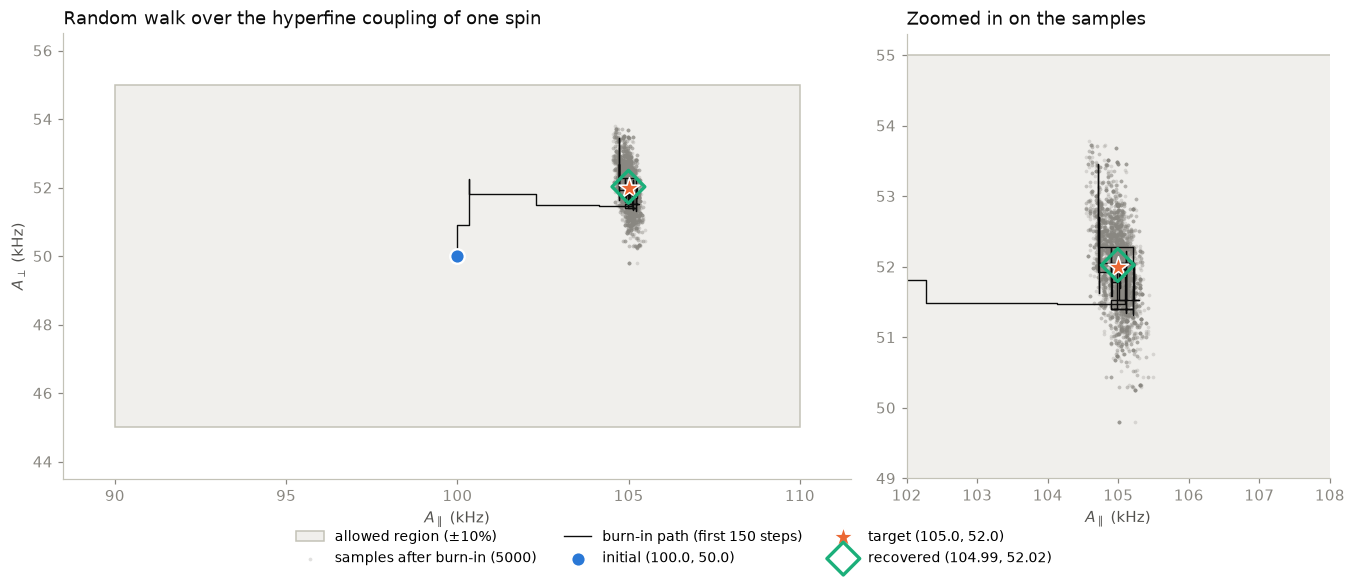

In [5]:
def draw_walk(ax, burn_in_steps):
    ax.add_patch(Rectangle(
        (A_PAR - HALF_PAR, A_PERP - HALF_PERP), 2 * HALF_PAR, 2 * HALF_PERP,
        facecolor=C_REGION, edgecolor="#c3c2b7", lw=1.0, zorder=0,
        label="allowed region (±10%)"))
    ax.scatter(post_par, post_perp, s=6, color=C_MUTED, alpha=0.25, linewidths=0,
               zorder=1, label=f"samples after burn-in ({N_STEPS - N_BURN})")
    ax.plot(walk_par[: burn_in_steps + 1], walk_perp[: burn_in_steps + 1],
            color=C_INK, lw=0.9, zorder=2,
            label=f"burn-in path (first {burn_in_steps} steps)")
    ax.scatter([A_PAR], [A_PERP], s=90, marker="o", color=C_INITIAL,
               edgecolor="white", linewidths=1.5, zorder=4,
               label=f"initial ({A_PAR:.1f}, {A_PERP:.1f})")
    ax.scatter([TRUE_PAR], [TRUE_PERP], s=200, marker="*", color=C_TARGET,
               edgecolor="white", linewidths=1.0, zorder=5,
               label=f"target ({TRUE_PAR:.1f}, {TRUE_PERP:.1f})")
    ax.scatter([rec_par], [rec_perp], s=230, marker="D", facecolor="none",
               edgecolor=C_RECOVERED, linewidths=2.2, zorder=6,
               label=f"recovered ({rec_par:.2f}, {rec_perp:.2f})")
    ax.set_aspect("equal")
    ax.set_xlabel(r"$A_\parallel$ (kHz)")


# The walk reaches the target long before burn-in ends; drawing every burn-in
# step would bury the approach under the scribble that follows it.
PATH_STEPS = 150

fig, (full, zoom) = plt.subplots(1, 2, figsize=(12.5, 5.0),
                                 gridspec_kw={"width_ratios": [1.9, 1]})
draw_walk(full, PATH_STEPS)
full.set_xlim(A_PAR - 1.15 * HALF_PAR, A_PAR + 1.15 * HALF_PAR)
full.set_ylim(A_PERP - 1.3 * HALF_PERP, A_PERP + 1.3 * HALF_PERP)
full.set_ylabel(r"$A_\perp$ (kHz)")
full.set_title("Random walk over the hyperfine coupling of one spin", loc="left",
               color=C_INK)

draw_walk(zoom, PATH_STEPS)
zoom.set_xlim(TRUE_PAR - 3.0, TRUE_PAR + 3.0)
zoom.set_ylim(A_PERP - 1.0, A_PERP + HALF_PERP + 0.3)
zoom.set_title("Zoomed in on the samples", loc="left", color=C_INK)

handles, labels = full.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

## 5. The signals

Top: the simulated data, with the signal at the table value where the walk
started and the signal at the recovered coupling. Bottom: the same two
curves with the data subtracted, where the difference is easier to read. The
band is the noise that was added to the data.

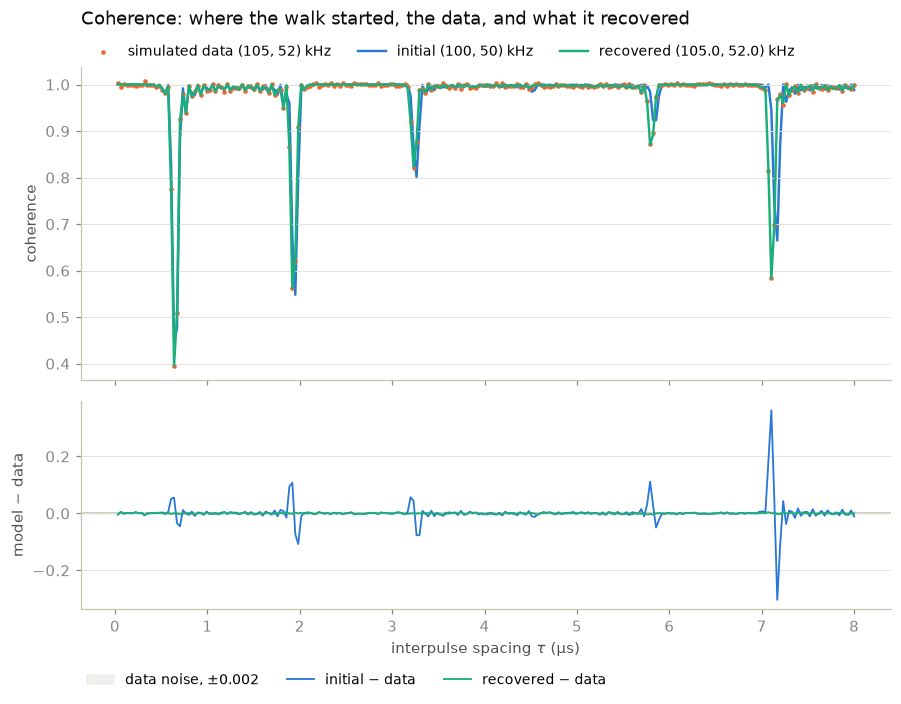

rms residual, initial  : 0.0380
rms residual, recovered: 0.0020   (data noise 0.002)


In [6]:
sig_initial = simulate_coherence(initial, blank, table, model)
sig_recovered = simulate_coherence(recovered, blank, table, model)
measured = data.data_all
tau_us = tau * 1e3

fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(9.5, 6.4), sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})

top.scatter(tau_us, measured, s=9, color=C_TARGET, linewidths=0, zorder=2,
            label=f"simulated data ({TRUE_PAR:.0f}, {TRUE_PERP:.0f}) kHz")
top.plot(tau_us, sig_initial, color=C_INITIAL, lw=1.6, zorder=1,
         label=f"initial ({A_PAR:.0f}, {A_PERP:.0f}) kHz")
top.plot(tau_us, sig_recovered, color=C_RECOVERED, lw=1.6, zorder=3,
         label=f"recovered ({rec_par:.1f}, {rec_perp:.1f}) kHz")
top.set_ylabel("coherence")
top.set_title("Coherence: where the walk started, the data, and what it recovered",
              loc="left", color=C_INK, pad=28)
top.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=3, fontsize=9,
           borderaxespad=0.2)
top.grid(axis="y")

bottom.axhspan(-DATA_NOISE, DATA_NOISE, color=C_REGION, zorder=0,
               label=f"data noise, ±{DATA_NOISE}")
bottom.axhline(0.0, color="#c3c2b7", lw=1.0, zorder=1)
bottom.plot(tau_us, sig_initial - measured, color=C_INITIAL, lw=1.2, zorder=2,
            label="initial − data")
bottom.plot(tau_us, sig_recovered - measured, color=C_RECOVERED, lw=1.2,
            zorder=3, label="recovered − data")
bottom.set_xlabel(r"interpulse spacing $\tau$ (µs)")
bottom.set_ylabel("model − data")
bottom.legend(loc="upper left", bbox_to_anchor=(0.0, -0.28), ncols=3,
              fontsize=9, borderaxespad=0.0)
bottom.grid(axis="y")
plt.show()

rms_initial = np.sqrt(np.mean((sig_initial - measured) ** 2))
rms_recovered = np.sqrt(np.mean((sig_recovered - measured) ** 2))
print(f"rms residual, initial  : {rms_initial:.4f}")
print(f"rms residual, recovered: {rms_recovered:.4f}   (data noise {DATA_NOISE})")